In [1]:
# ===============================
# IMPORTS
# ===============================
import os
import numpy as np
import pandas as pd
import librosa
import random
from tqdm import tqdm

from tensorflow.keras.utils import to_categorical
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Flatten, Dense, Dropout
from tensorflow.keras.callbacks import EarlyStopping

from sklearn.model_selection import train_test_split
from sklearn.metrics import confusion_matrix, classification_report
from sklearn.utils.class_weight import compute_class_weight

import matplotlib.pyplot as plt
import seaborn as sns


In [2]:
# ===============================
# PATHS
# ===============================
DATA_PATH = r"D:\Test 1\dataset\ASVspoof2019_LA_train\flac"
PROTOCOL_PATH = r"D:\Test 1\dataset\ASVspoof2019_LA_train\train_protocol.txt"


In [3]:
# ===============================
# CONSTANTS
# ===============================
SAMPLE_RATE = 16000
N_MFCC = 40
MAX_LEN = 157


In [4]:
# ===============================
# AUGMENTATION FUNCTIONS
# ===============================
def add_noise(y):
    noise = np.random.randn(len(y))
    return y + 0.005 * noise

def time_stretch(y):
    return librosa.effects.time_stretch(y, rate=random.uniform(0.9, 1.1))

In [5]:
# ===============================
# MFCC EXTRACTION
# ===============================
def extract_mfcc(y, sr):
    mfcc = librosa.feature.mfcc(y=y, sr=sr, n_mfcc=N_MFCC)

    # Strong normalization
    mfcc = (mfcc - np.mean(mfcc)) / (np.std(mfcc) + 1e-6)

    if mfcc.shape[1] < MAX_LEN:
        pad = MAX_LEN - mfcc.shape[1]
        mfcc = np.pad(mfcc, ((0,0),(0,pad)))
    else:
        mfcc = mfcc[:, :MAX_LEN]

    return mfcc


In [6]:
# ===============================
# LOAD PROTOCOL
# ===============================
df = pd.read_csv(PROTOCOL_PATH, sep=" ", header=None)
df.columns = ["speaker", "file", "x1", "x2", "label"]

df["label"] = df["label"].map({
    "bonafide": 1,
    "spoof": 0
})

print("Dataset loaded:", df.shape)

Dataset loaded: (5000, 5)


In [7]:
# ===============================
# LOAD DATA + AUGMENTATION (BOTH CLASSES)
# ===============================
X = []
y_labels = []

print("\nProcessing audio with augmentation...\n")

for _, row in tqdm(df.iterrows(), total=len(df)):
    file_path = os.path.join(DATA_PATH, row["file"] + ".flac")

    if not os.path.exists(file_path):
        continue

    try:
        audio, sr = librosa.load(file_path, sr=SAMPLE_RATE)
        label = row["label"]

        # ORIGINAL
        X.append(extract_mfcc(audio, sr))
        y_labels.append(label)

        # -------------------------------
        # AUGMENTATION FOR BOTH CLASSES
        # -------------------------------

        # Noise
        aug1 = add_noise(audio)
        X.append(extract_mfcc(aug1, sr))
        y_labels.append(label)

        # Time stretch
        aug2 = time_stretch(audio)
        X.append(extract_mfcc(aug2, sr))
        y_labels.append(label)

    except:
        continue


Processing audio with augmentation...



100%|██████████| 5000/5000 [04:20<00:00, 19.18it/s]


In [8]:
# ===============================
# FINAL DATA
# ===============================
X = np.array(X)
y_labels = np.array(y_labels)

print("\nDataset size after augmentation:", X.shape)

# Convert labels
y = to_categorical(y_labels, 2)

# Reshape for CNN
X = X.reshape(-1, 40, 157, 1)



Dataset size after augmentation: (15000, 40, 157)


In [9]:
# ===============================
# CLASS WEIGHTS (IMPORTANT)
# ===============================
labels = np.argmax(y, axis=1)

class_weights = compute_class_weight(
    class_weight='balanced',
    classes=np.unique(labels),
    y=labels
)

class_weights = dict(enumerate(class_weights))
print("Class weights:", class_weights)

Class weights: {0: np.float64(1.0), 1: np.float64(1.0)}


In [10]:
# ===============================
# TRAIN / VALID SPLIT
# ===============================
X_train, X_val, y_train, y_val = train_test_split(
    X, y, test_size=0.2, random_state=42
)

In [11]:
# ===============================
# MODEL (REGULARIZED CNN)
# ===============================
model = Sequential([
    Conv2D(32, (3,3), activation='relu', input_shape=(40,157,1)),
    MaxPooling2D(2,2),
    Dropout(0.2),

    Conv2D(64, (3,3), activation='relu'),
    MaxPooling2D(2,2),
    Dropout(0.2),

    Conv2D(128, (3,3), activation='relu'),
    MaxPooling2D(2,2),
    Dropout(0.3),

    Flatten(),
    Dense(128, activation='relu'),
    Dropout(0.4),

    Dense(2, activation='softmax')
])

model.compile(
    optimizer='adam',
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

model.summary()

c:\Users\Hp\AppData\Local\Programs\Python\Python311\Lib\site-packages\keras\src\layers\convolutional\base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 38, 155, 32)    │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 19, 77, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 19, 77, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 17, 75, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 8, 37, 64)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 8, 37, 64)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 6, 35, 128)     │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 3, 17, 128)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 3, 17, 128)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 6528)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │       835,712 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 2)              │           258 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 928,642 (3.54 MB)

 Trainable params: 928,642 (3.54 MB)

 Non-trainable params: 0 (0.00 B)

In [12]:
# ===============================
# TRAIN
# ===============================
early_stop = EarlyStopping(
    monitor='val_loss',
    patience=4,
    restore_best_weights=True
)

history = model.fit(
    X_train, y_train,
    validation_data=(X_val, y_val),
    epochs=30,
    batch_size=32,
    callbacks=[early_stop],
    class_weight=class_weights
)


Epoch 1/30
375/375 ━━━━━━━━━━━━━━━━━━━━ 15s 37ms/step - accuracy: 0.8761 - loss: 0.2854 - val_accuracy: 0.9453 - val_loss: 0.1403
Epoch 2/30
375/375 ━━━━━━━━━━━━━━━━━━━━ 13s 35ms/step - accuracy: 0.9557 - loss: 0.1263 - val_accuracy: 0.9500 - val_loss: 0.1179
Epoch 3/30
375/375 ━━━━━━━━━━━━━━━━━━━━ 14s 36ms/step - accuracy: 0.9756 - loss: 0.0737 - val_accuracy: 0.9853 - val_loss: 0.0440
Epoch 4/30
375/375 ━━━━━━━━━━━━━━━━━━━━ 14s 37ms/step - accuracy: 0.9810 - loss: 0.0550 - val_accuracy: 0.9870 - val_loss: 0.0330
Epoch 5/30
375/375 ━━━━━━━━━━━━━━━━━━━━ 13s 36ms/step - accuracy: 0.9837 - loss: 0.0466 - val_accuracy: 0.9917 - val_loss: 0.0228
Epoch 6/30
375/375 ━━━━━━━━━━━━━━━━━━━━ 14s 36ms/step - accuracy: 0.9857 - loss: 0.0400 - val_accuracy: 0.9890 - val_loss: 0.0277
Epoch 7/30
375/375 ━━━━━━━━━━━━━━━━━━━━ 14s 36ms/step - accuracy: 0.9865 - loss: 0.0423 - val_accuracy: 0.9887 - val_loss: 0.0270
Epoch 8/30
375/375 ━━━━━━━━━━━━━━━━━━━━ 16s 43ms/step - accuracy: 0.9908 - loss: 0.0269 - 

In [13]:
# ===============================
# SAVE MODEL
# ===============================
os.makedirs("models", exist_ok=True)
model.save("models/deepfake_modelv3.keras")

print("\nModel saved!")


Model saved!


94/94 ━━━━━━━━━━━━━━━━━━━━ 1s 14ms/step


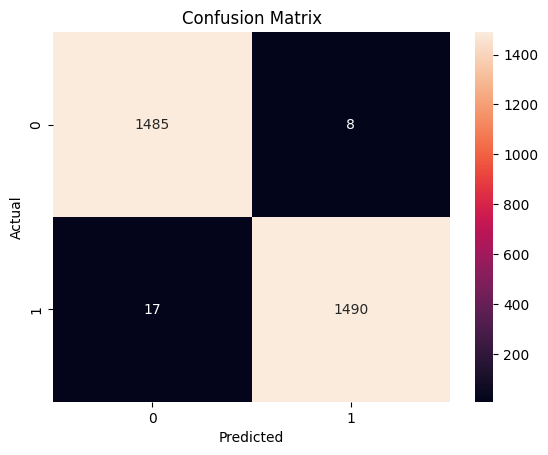


Classification Report:

              precision    recall  f1-score   support

           0       0.99      0.99      0.99      1493
           1       0.99      0.99      0.99      1507

    accuracy                           0.99      3000
   macro avg       0.99      0.99      0.99      3000
weighted avg       0.99      0.99      0.99      3000



In [14]:
# ===============================
# EVALUATION
# ===============================
y_pred = model.predict(X_val)
y_pred = np.argmax(y_pred, axis=1)
y_true = np.argmax(y_val, axis=1)

cm = confusion_matrix(y_true, y_pred)

plt.figure()
sns.heatmap(cm, annot=True, fmt='d')
plt.title("Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

print("\nClassification Report:\n")
print(classification_report(y_true, y_pred))

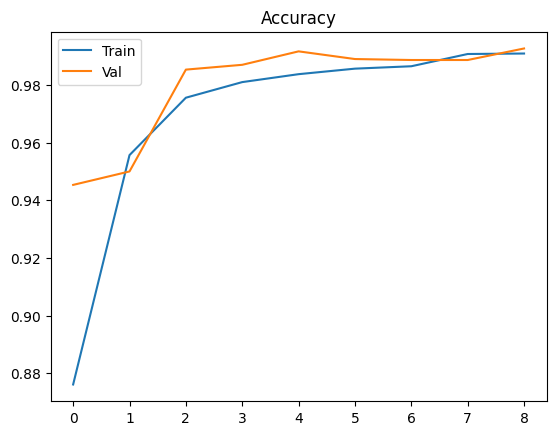

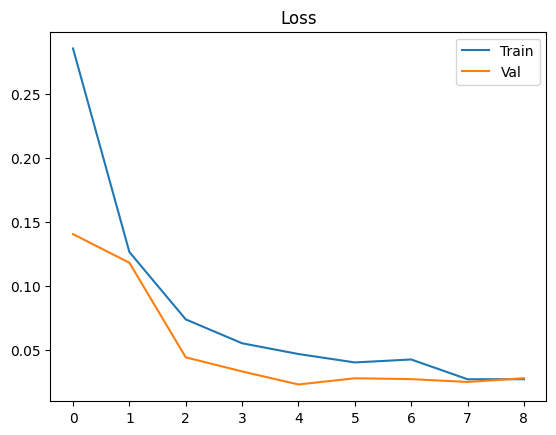

In [15]:
# ===============================
# TRAINING GRAPHS
# ===============================
plt.figure()
plt.plot(history.history['accuracy'])
plt.plot(history.history['val_accuracy'])
plt.title("Accuracy")
plt.legend(["Train", "Val"])
plt.show()

plt.figure()
plt.plot(history.history['loss'])
plt.plot(history.history['val_loss'])
plt.title("Loss")
plt.legend(["Train", "Val"])
plt.show()